In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

In [2]:
def plot_train_test_predict(train_df, test_df, predict_df=None, areas=[6,5]):
    """
    Визуализирует динамику заказов такси для указанных районов разными цветами:
    синим — train, оранжевым — validation, зелёным — предсказания.

    Параметры:
    ----------
    train_df : pandas.DataFrame
        Тренировочные данные с временным индексом и колонками по районам.
    test_df : pandas.DataFrame
        Валидационные (тестовые) данные с теми же колонками и индексом.
    predict_df : pandas.DataFrame
        Предсказанные значения (длина и индексы совпадают с test_df).
    areas : list of str
        Список названий колонок для визуализации (например, [0, 6])

    Возвращает:
    -----------
    None (строит график matplotlib)
    """

    plt.figure(figsize=(12, 4*len(areas)))
    for i, area in enumerate(areas, 1):
        plt.subplot(len(areas), 1, i)
        plt.plot(train_df.index, train_df[f'Pickup Community Area_{area}'], label='Train', color='blue')
        plt.plot(test_df.index, test_df[f'Pickup Community Area_{area}'], label='Test', color='orange')
        if predict_df is not None:
            plt.plot(predict_df.index, predict_df[f'Pickup Community Area_{area}'], label='Predict', color='green')
        plt.title(f'Area: {area}')
        plt.xlabel('Time')
        plt.ylabel('Number of orders')
        plt.legend()
        plt.grid(True)
        plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d')) # %Y-%m-%d %H:%M
        plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [3]:
df = pd.read_csv('../datasets/taxi_pickups_area.csv', parse_dates=['Trip Start Timestamp'])
# Установка индекса времени
df.set_index('Trip Start Timestamp', inplace=True)
df

,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5,Pickup Community Area_6,Pickup Community Area_7,Pickup Community Area_8,Pickup Community Area_9,...,Pickup Community Area_68,Pickup Community Area_69,Pickup Community Area_70,Pickup Community Area_71,Pickup Community Area_72,Pickup Community Area_73,Pickup Community Area_74,Pickup Community Area_75,Pickup Community Area_76,Pickup Community Area_77
Trip Start Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-04-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2019-04-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2019-04-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
2019-04-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2019-04-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-23 22:45:00,4.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
2019-06-23 23:00:00,3.0,0.0,0.0,1.0,0.0,0.0,5.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
2019-06-23 23:15:00,3.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,11.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0


In [4]:
train = df.iloc[:-672]
test = df.iloc[-672:]

print('Размер тренировочной выборки:', train.shape)
print('Размер тестовой выборки:', test.shape)

Размер тренировочной выборки: (7392, 78)
Размер тестовой выборки: (672, 78)


In [5]:
train

,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5,Pickup Community Area_6,Pickup Community Area_7,Pickup Community Area_8,Pickup Community Area_9,...,Pickup Community Area_68,Pickup Community Area_69,Pickup Community Area_70,Pickup Community Area_71,Pickup Community Area_72,Pickup Community Area_73,Pickup Community Area_74,Pickup Community Area_75,Pickup Community Area_76,Pickup Community Area_77
Trip Start Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-04-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2019-04-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2019-04-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
2019-04-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2019-04-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-16 22:45:00,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0
2019-06-16 23:00:00,4.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,9.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0
2019-06-16 23:15:00,4.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,1.0


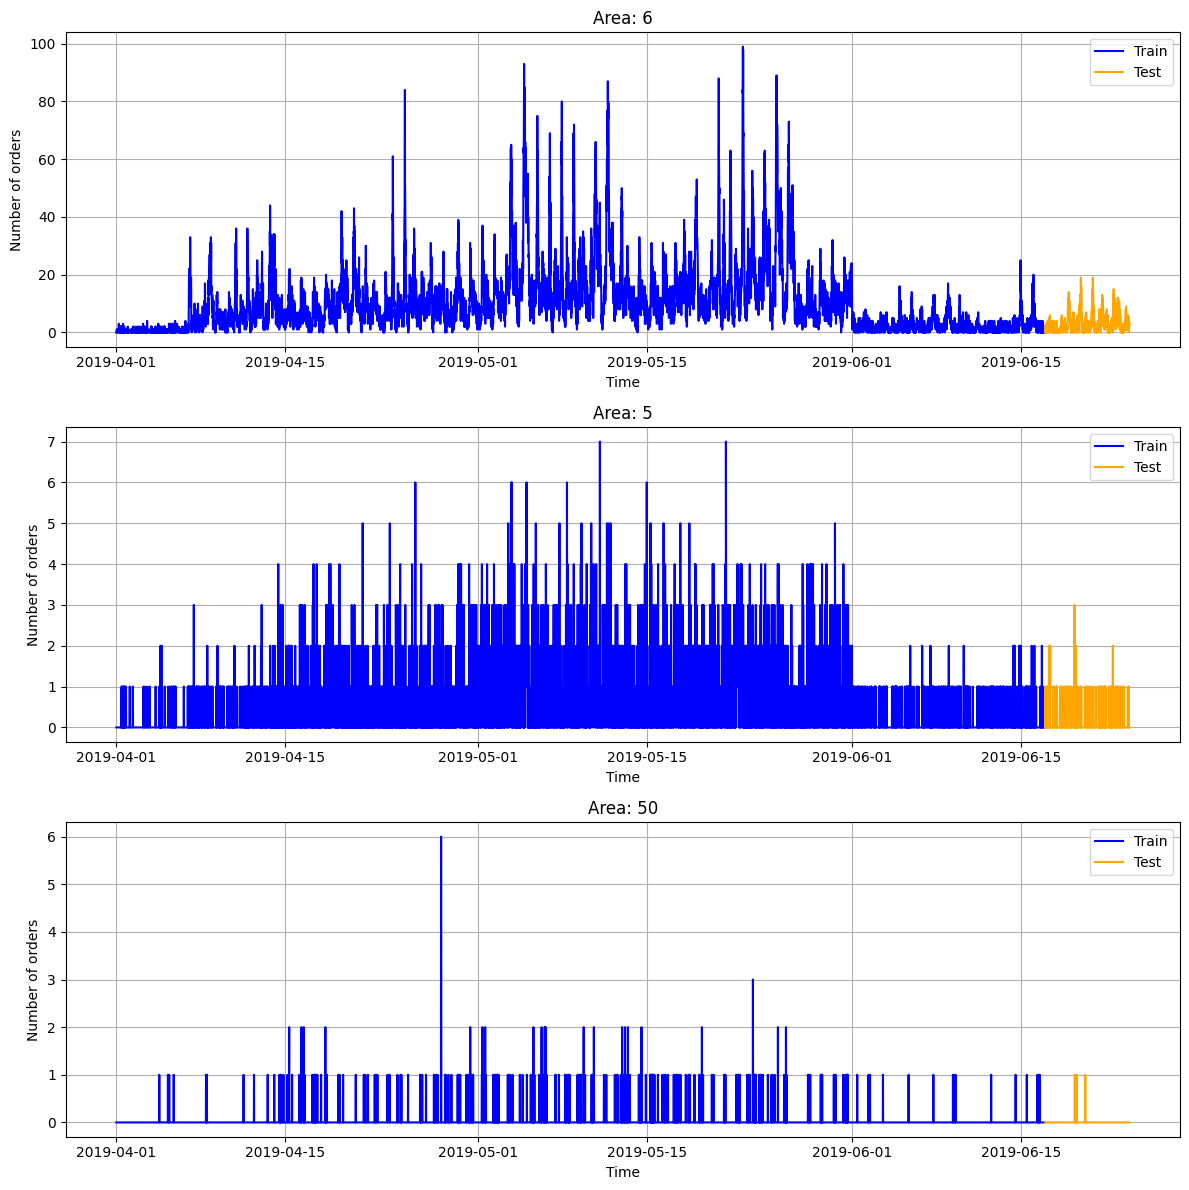

In [6]:
# Визуаизируем некоторые области
plot_train_test_predict(
    train_df=train,
    test_df=test,
    areas=[6,5,50]
    )

### 1. Наивные средние значения

- Для каждого домена сделайте прогноз, используя глобальное среднее значение для этого домена для следующих 673 интервалов.

- Рассчитайте среднюю абсолютную ошибку (MAE) для вашего собственного набора проверочных данных.

In [7]:
# Рассчёт глобального среднего для каждого района (по столбцам Pickup Community Area_0 ... Pickup Community Area_76)
mean_per_area = train.mean()

# Прогноз - на каждый шаг теста ставим среднее значение
test_predict = pd.DataFrame(np.tile(mean_per_area.values, (len(test), 1)),
                        index=test.index,
                        columns=mean_per_area.index)

test_predict

,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5,Pickup Community Area_6,Pickup Community Area_7,Pickup Community Area_8,Pickup Community Area_9,...,Pickup Community Area_68,Pickup Community Area_69,Pickup Community Area_70,Pickup Community Area_71,Pickup Community Area_72,Pickup Community Area_73,Pickup Community Area_74,Pickup Community Area_75,Pickup Community Area_76,Pickup Community Area_77
Trip Start Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-06-17 00:00:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-17 00:15:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-17 00:30:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-17 00:45:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-17 01:00:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-23 22:45:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-23 23:00:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297
2019-06-23 23:15:00,16.599702,1.165449,1.159497,2.80506,0.920049,0.598891,10.332927,5.867695,89.722403,0.016369,...,0.080628,0.122159,0.068588,0.124729,0.02638,0.104708,0.011634,0.068994,32.456169,2.224297


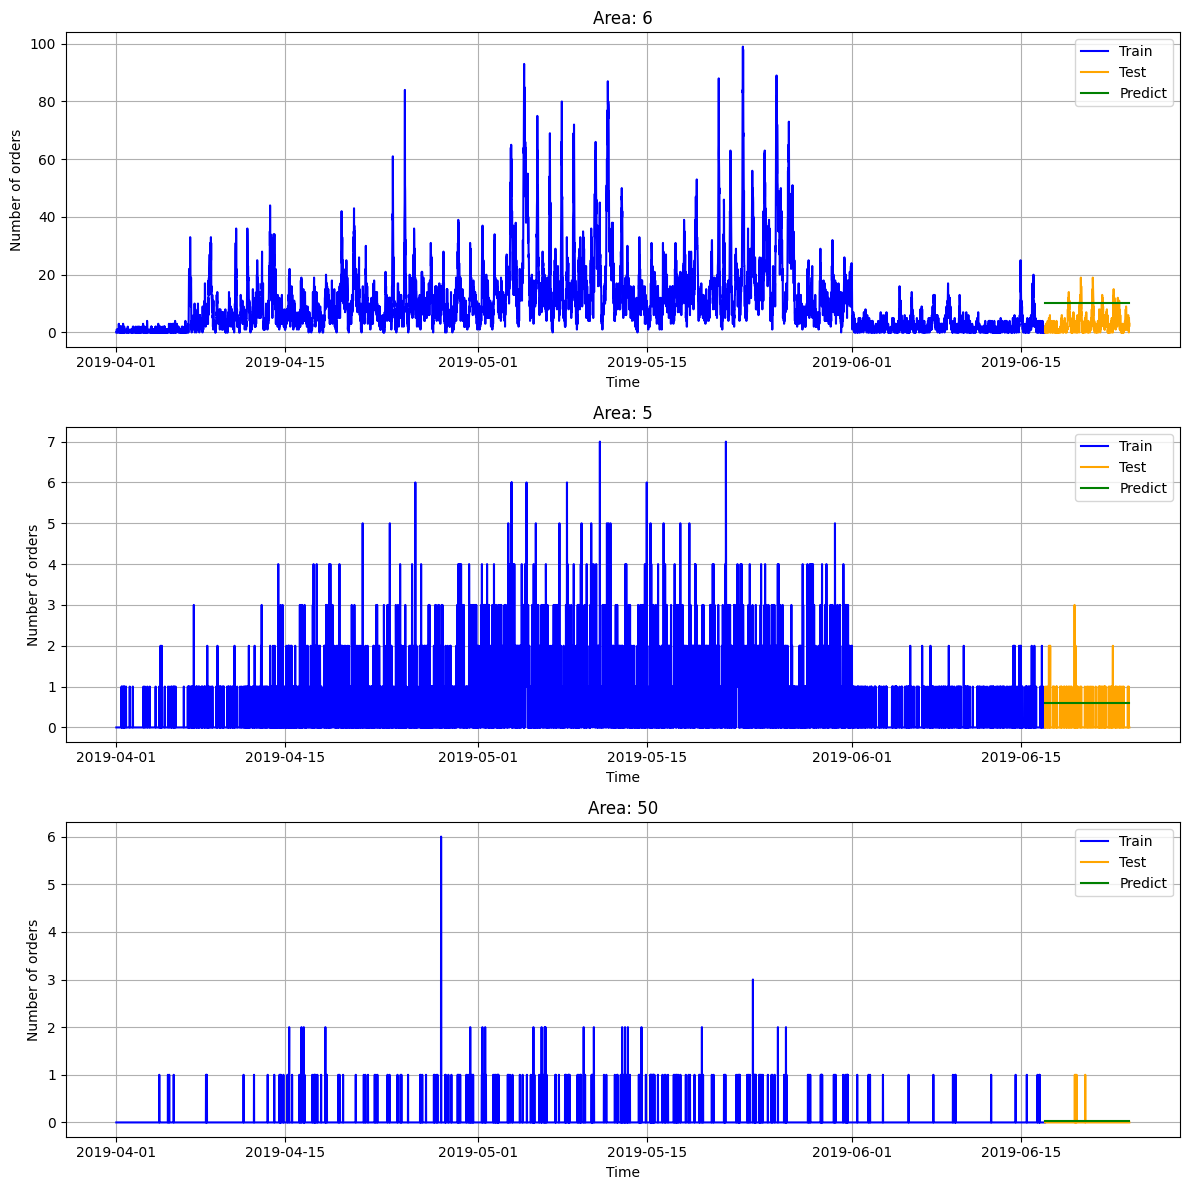

In [8]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

In [9]:
MAE_global_mean = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке: {MAE_global_mean}')

MAE на тестовой выборке: 3.1035


### 2. Скользящая средняя

In [10]:
len_train = train.shape[0]
len_train

7392

In [11]:
def moving_average_forecast(train_df, length=672, window=2):
    # создадим пустой фрейм с предсказаниями и пока заполним его -1

    # Получаем последнюю временную метку из исходного df
    last_timestamp = train_df.index[-1]

    # Создаем новый индекс с 672 периодами и частотой 15 минут, начиная со следующего шага после last_timestamp
    new_index = pd.date_range(start=last_timestamp + pd.Timedelta(minutes=15), periods=length, freq='15min')

    # Создаем пустой DataFrame с нужным индексом и колонками, заполняем все -1
    new_df = pd.DataFrame(-1.0, index=new_index, columns=train_df.columns)
    len_train = train.shape[0] # Количество строк в тренировочном датасете
    for i in range(len(new_df)):
        subset = train_df.iloc[-(length + window) + i :-length + i]
        mean = subset.mean().to_list()
        new_df.iloc[i] = mean

    return new_df

100%|██████████| 250/250 [01:19<00:00,  3.15it/s]

МИнимальное MAE:    window     MAE
1     3.0  0.3987
2     5.0  0.3999


<Axes: xlabel='window'>

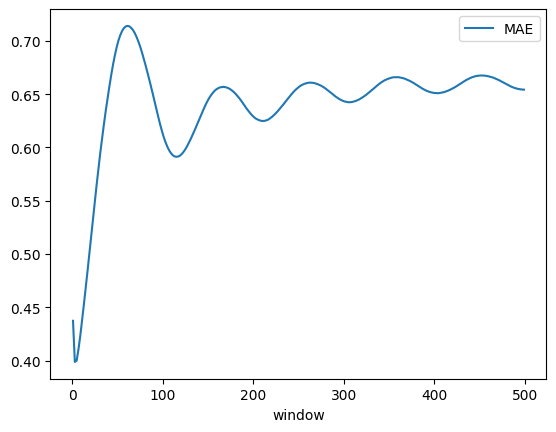

In [12]:
# Посмотрим как зависиит Метрика от величины окна

temp = pd.DataFrame(columns=['window', 'MAE'])
for i in tqdm(range(1,500,2)):
    test_predict = moving_average_forecast(train_df=train, length=672, window=i)
    MAE_rolling_mean = round(mean_absolute_error(test, test_predict), 4)
    temp.loc[len(temp)] = [i, MAE_rolling_mean]

print('МИнимальное MAE:', temp.sort_values(by='MAE').head(2))
temp.plot(x='window', y='MAE')

In [13]:
test_predict = moving_average_forecast(train_df=train, length=672, window=3)
MAE_rolling_mean = round(mean_absolute_error(test, test_predict), 4)

MAE_rolling_mean = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке с окном 3: {MAE_rolling_mean}')

MAE на тестовой выборке с окном 3: 0.3987


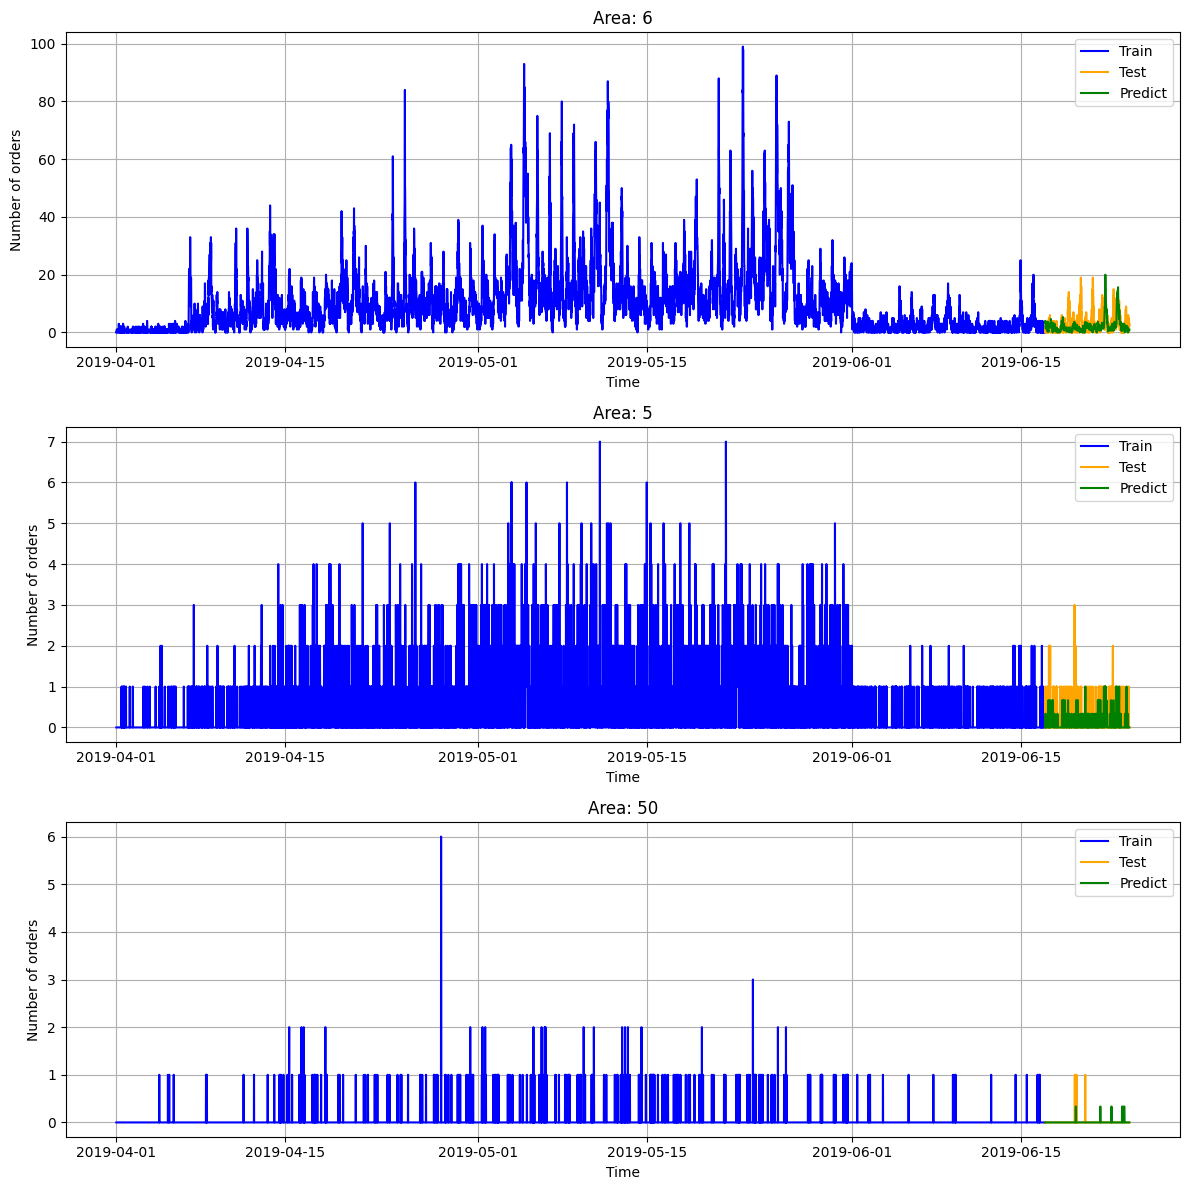

In [14]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

### 3. Экспоненциальное сглаживание
1. Простое экспоненциальное сглаживание:

- Подходит, когда данные не имеют ярко выраженного тренда и сезонности.
- Каждое новое значение прогноза получается как взвешенная сумма текущего наблюдения и предыдущего прогноза, причем более свежие данные имеют больший вес (экспоненциально уменьшающийся вес для старых данных).
- Чем выше коэффициент сглаживания (альфа), тем быстрее реагирует прогноз на новые изменения

2. Двойное экспоненциальное сглаживание (Метод Хольта):
- Используется, если у данных есть тренд (постепенное увеличение или уменьшение).
- Модель учитывает не только уровень временного ряда, но и тренд изменения — есть две компоненты: одна сглаживает уровень, другая — тренд.
- Благодаря этому прогнозы умеют «двигаться» вместе с трендом и лучше описывают растущие или падающие данные

3. Тройное экспоненциальное сглаживание (Метод Хольта-Винтерса):

- Добавляет к уровню и тренду ещё и сезонную компоненту (повторяющиеся циклы, например, по дням недели или часам суток).
- Сезонность моделируется как набор сезонных коэффициентов, которые корректируют прогноз в зависимости от времени в сезоне. Например, если это недельная сезонность, то у каждого дня недели свой коэффициент.
- Позволяет прогнозировать с учётом тренда и сезонных колебаний, что делает модель мощной и гибкой для реальных временных рядов с регулярными повторениями

In [15]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

import warnings
warnings.filterwarnings('ignore')


#### 3.1. Простое экспоненциальное сглаживание
Без учета тренда и без учета сезонности

In [16]:
areas = df.columns.to_list()

test_predict = pd.DataFrame(index=test.index, columns=areas)

for area in tqdm(areas):
    ts_train = train[area]

    # Обучаем модель тройного экспоненциального сглаживания
    model = ExponentialSmoothing(
        ts_train,trend=None,
        seasonal=None)
    fit = model.fit()

    # Прогноз на 673 шага вперед
    forecast = fit.forecast(672)

    # Записываем в итоговый датафрейм
    test_predict[area] = forecast

  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:01<00:00, 43.64it/s]


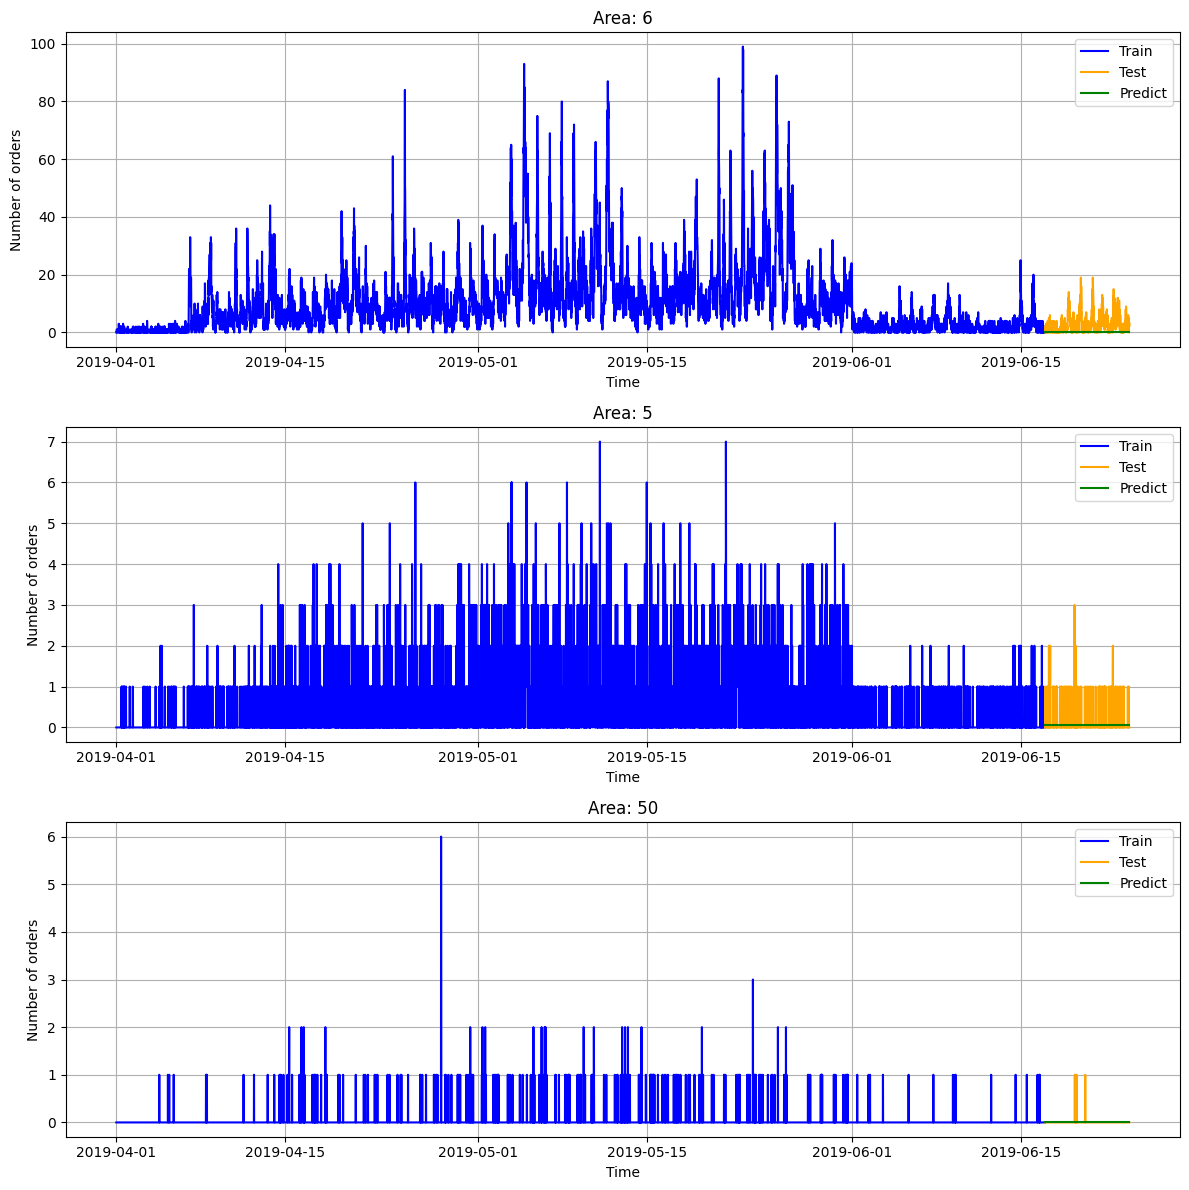

In [17]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

In [18]:
MAE_exponencial_smooth_simple = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке: {MAE_exponencial_smooth_simple}')

MAE на тестовой выборке: 0.7562


#### 3.2. Двойное экспоненциальное сглаживание (Хольта)
С учетом тренда и без учета сезонности

In [19]:
areas = df.columns.to_list()

test_predict = pd.DataFrame(index=test.index, columns=areas)

for area in tqdm(areas):
    ts_train = train[area]

    # Обучаем модель тройного экспоненциального сглаживания
    model = ExponentialSmoothing(
        ts_train,
        trend='add',
        seasonal=None)
    fit = model.fit()

    # Прогноз на 673 шага вперед
    forecast = fit.forecast(672)

    # Записываем в итоговый датафрейм
    test_predict[area] = forecast

  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:18<00:00,  4.17it/s]


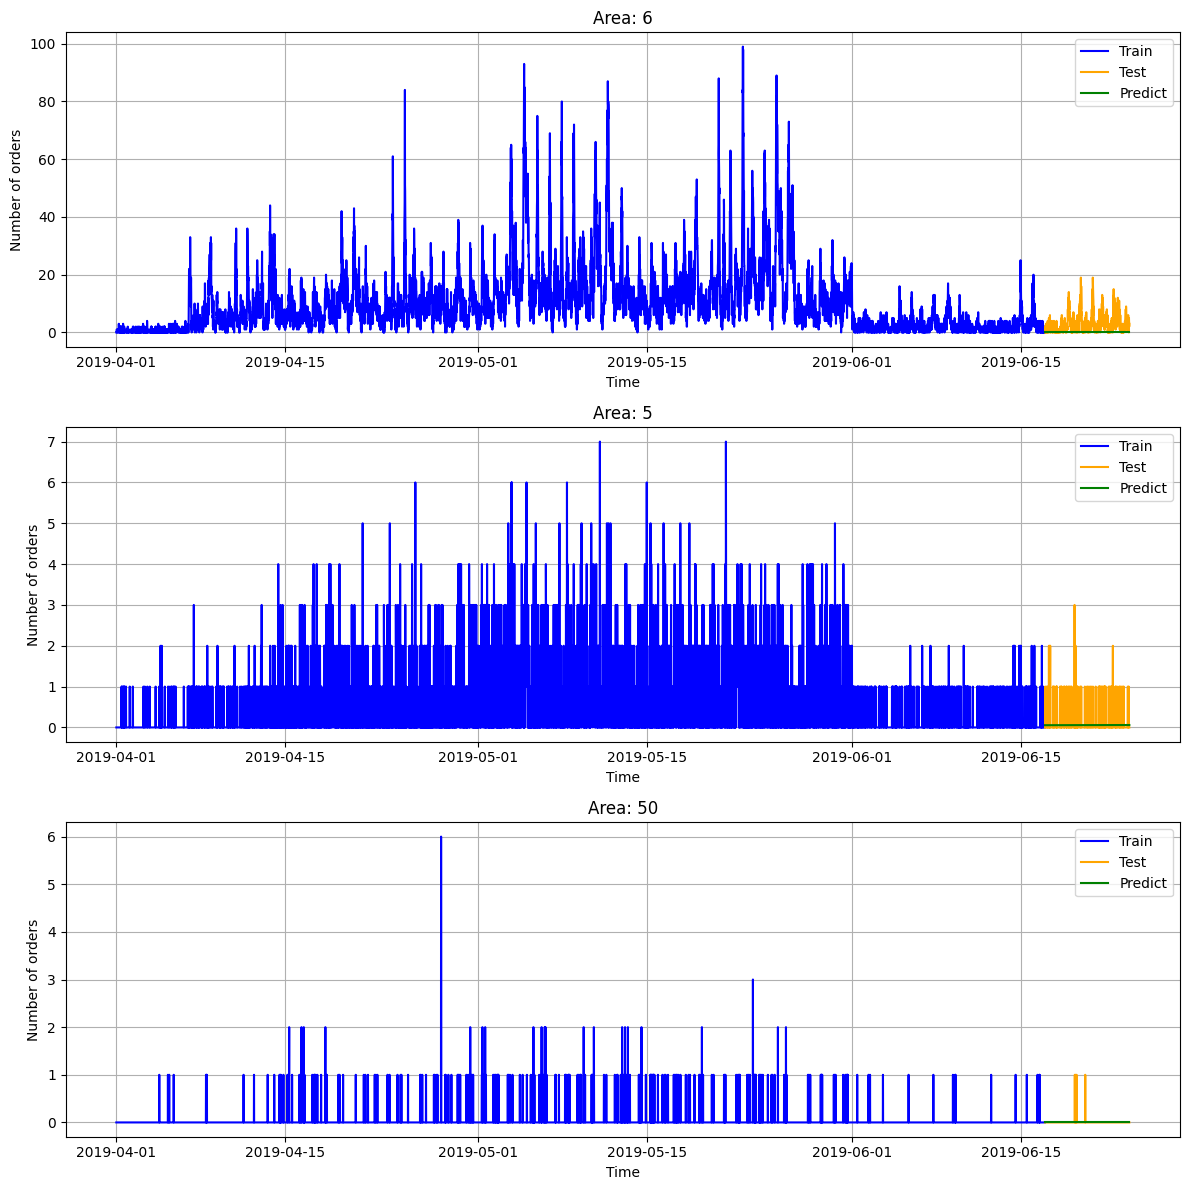

In [20]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

In [21]:
MAE_exponencial_smooth_double = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке: {MAE_exponencial_smooth_double}')

MAE на тестовой выборке: 5.1596


#### 3.3. Тройное экспоненциальное сглаживание (Хольта-Винтерса)
С учетом тренда и с учетом сезонности

In [22]:
areas = df.columns.to_list()

test_predict = pd.DataFrame(index=test.index, columns=areas)

for area in tqdm(areas):
    ts_train = train[area]

    # Обучаем модель тройного экспоненциального сглаживания
    model = ExponentialSmoothing(
        ts_train,
        trend='add',
        seasonal='add',
        seasonal_periods=4*24, # Дневная сезонность
        )
    fit = model.fit()

    # Прогноз на 673 шага вперед
    forecast = fit.forecast(672)

    # Записываем в итоговый датафрейм
    test_predict[area] = forecast

100%|██████████| 78/78 [03:04<00:00,  2.37s/it]


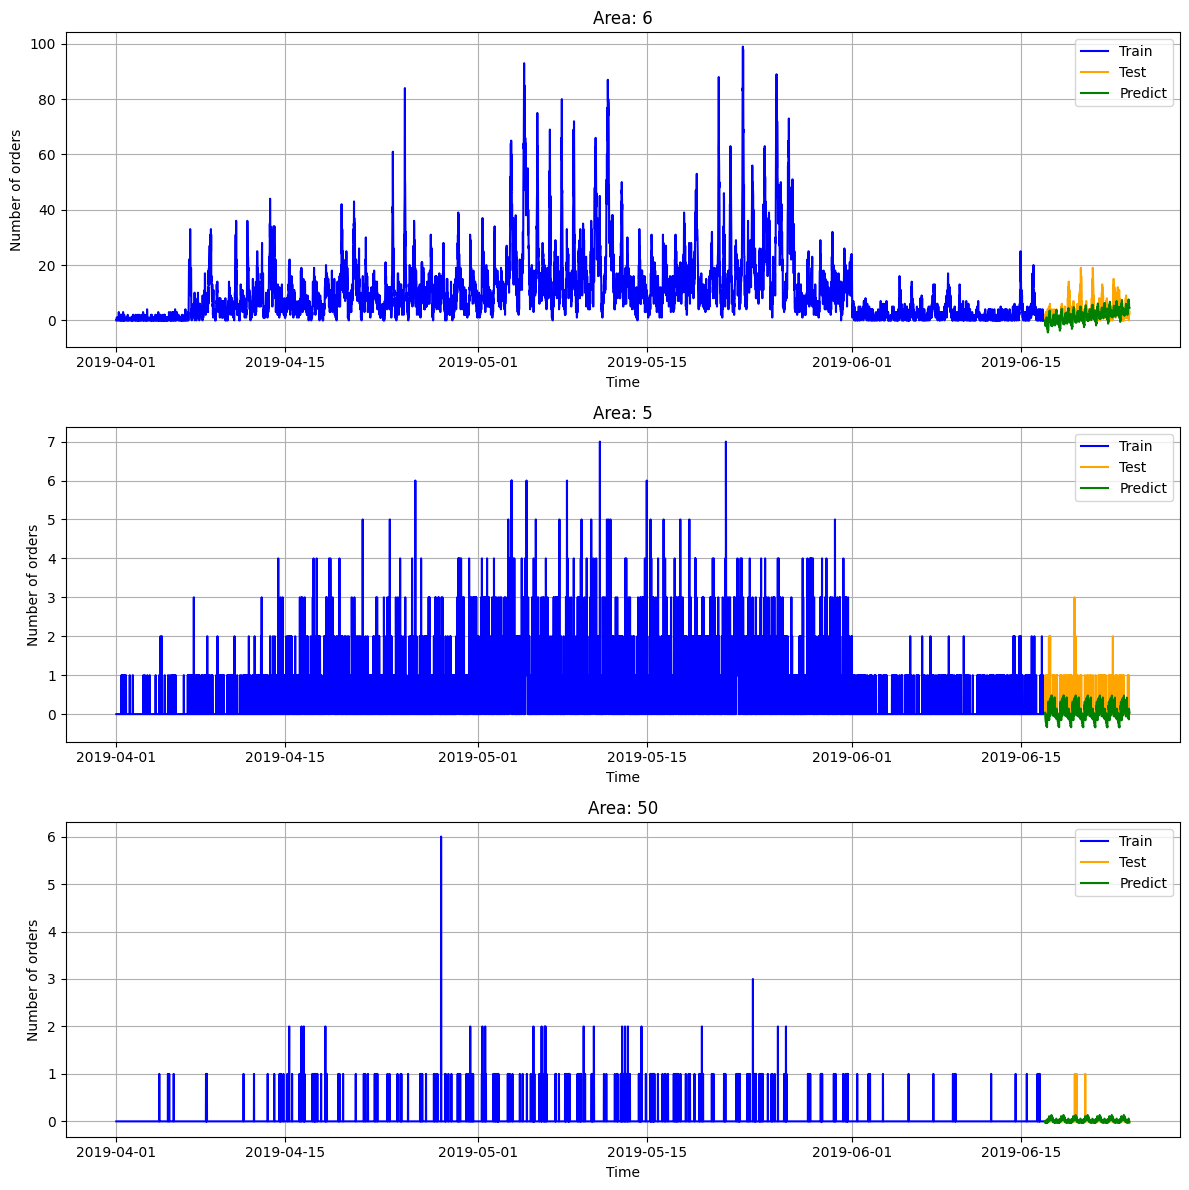

In [23]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

In [24]:
MAE_exponencial_smooth_triple = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке: {MAE_exponencial_smooth_triple}')

MAE на тестовой выборке: 1.8934


### 4. SARIMA

В ицкле выбираем лучшие параметры. Очень долгий алгоритм, поэтому не учитываем сезонность

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

areas = df.columns.to_list()

test_predict = pd.DataFrame(index=test.index, columns=areas)



for area in tqdm(areas):
    ts_train = train[area]
    # Перебор параметров SARIMA для минимального AIC
    p = d = q = range(0, 2)
    parameters = itertools.product(p, d, q)
    best_aic = float("inf")
    best_params = None
    for param in parameters:
        try:
            model = SARIMAX(ts_train,
                            order=(param[0], param[1], param[2]),
                            )
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = param
        except:
            continue

    # print(f"Лучшие параметры SARIMA: order={best_params[:3]}, seasonal_order={best_params[3:]}, AIC={best_aic}")

    # Обучение модели с лучшими параметрами
    model = SARIMAX(ts_train,
                    order=best_params[:3],
                    )
    results = model.fit(disp=False)

    # Прогноз на 672 шага вперед (4 * 24 часа * 7 дней)
    forecast = results.get_forecast(steps=672)
    forecast_values = forecast.predicted_mean

    # Записываем в итоговый датафрейм
    test_predict[area] = forecast_values.values
    # break

test_predict

  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [05:56<00:00,  4.57s/it]


,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5,Pickup Community Area_6,Pickup Community Area_7,Pickup Community Area_8,Pickup Community Area_9,...,Pickup Community Area_68,Pickup Community Area_69,Pickup Community Area_70,Pickup Community Area_71,Pickup Community Area_72,Pickup Community Area_73,Pickup Community Area_74,Pickup Community Area_75,Pickup Community Area_76,Pickup Community Area_77
Trip Start Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-06-17 00:00:00,1.675351,2.566039e-01,0.005168,0.329364,0.122652,0.047595,0.200855,0.290060,4.864838,0.004770,...,3.157614e-02,5.313604e-03,8.717355e-03,5.933642e-02,0.006972,1.026307e-02,0.002272,2.673451e-03,8.762576,0.183891
2019-06-17 00:15:00,1.731304,2.508682e-01,0.005117,0.325658,0.121707,0.047344,0.197392,0.259562,4.768066,0.004769,...,3.094869e-02,5.219836e-03,8.501287e-03,5.820800e-02,0.007473,1.002987e-02,0.002344,2.617471e-03,8.683665,0.182324
2019-06-17 00:30:00,1.721661,2.452608e-01,0.005067,0.321993,0.120769,0.047094,0.193988,0.262768,4.778895,0.004768,...,3.033371e-02,5.127724e-03,8.290575e-03,5.710105e-02,0.007509,9.801968e-03,0.002346,2.562664e-03,8.605465,0.180770
2019-06-17 00:45:00,1.723323,2.397786e-01,0.005017,0.318369,0.119837,0.046846,0.190642,0.262431,4.777683,0.004767,...,2.973095e-02,5.037237e-03,8.085085e-03,5.601514e-02,0.007511,9.579243e-03,0.002346,2.509005e-03,8.527969,0.179229
2019-06-17 01:00:00,1.723036,2.344190e-01,0.004968,0.314787,0.118914,0.046599,0.187355,0.262467,4.777819,0.004766,...,2.914016e-02,4.948346e-03,7.884688e-03,5.494989e-02,0.007511,9.361579e-03,0.002346,2.456469e-03,8.451171,0.177702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-23 22:45:00,1.723078,7.259569e-08,0.000007,0.000174,0.000703,0.001401,0.000002,0.262463,4.777805,0.004140,...,4.844912e-08,3.697985e-08,4.677898e-10,1.627262e-07,0.007511,2.255412e-09,0.002346,1.982409e-09,0.020998,0.000610
2019-06-23 23:00:00,1.723078,7.097301e-08,0.000007,0.000172,0.000697,0.001394,0.000002,0.262463,4.777805,0.004139,...,4.748639e-08,3.632728e-08,4.561952e-10,1.596316e-07,0.007511,2.204164e-09,0.002346,1.940900e-09,0.020809,0.000605
2019-06-23 23:15:00,1.723078,6.938660e-08,0.000007,0.000170,0.000692,0.001387,0.000002,0.262463,4.777805,0.004138,...,4.654279e-08,3.568623e-08,4.448880e-10,1.565958e-07,0.007511,2.154080e-09,0.002346,1.900259e-09,0.020621,0.000599


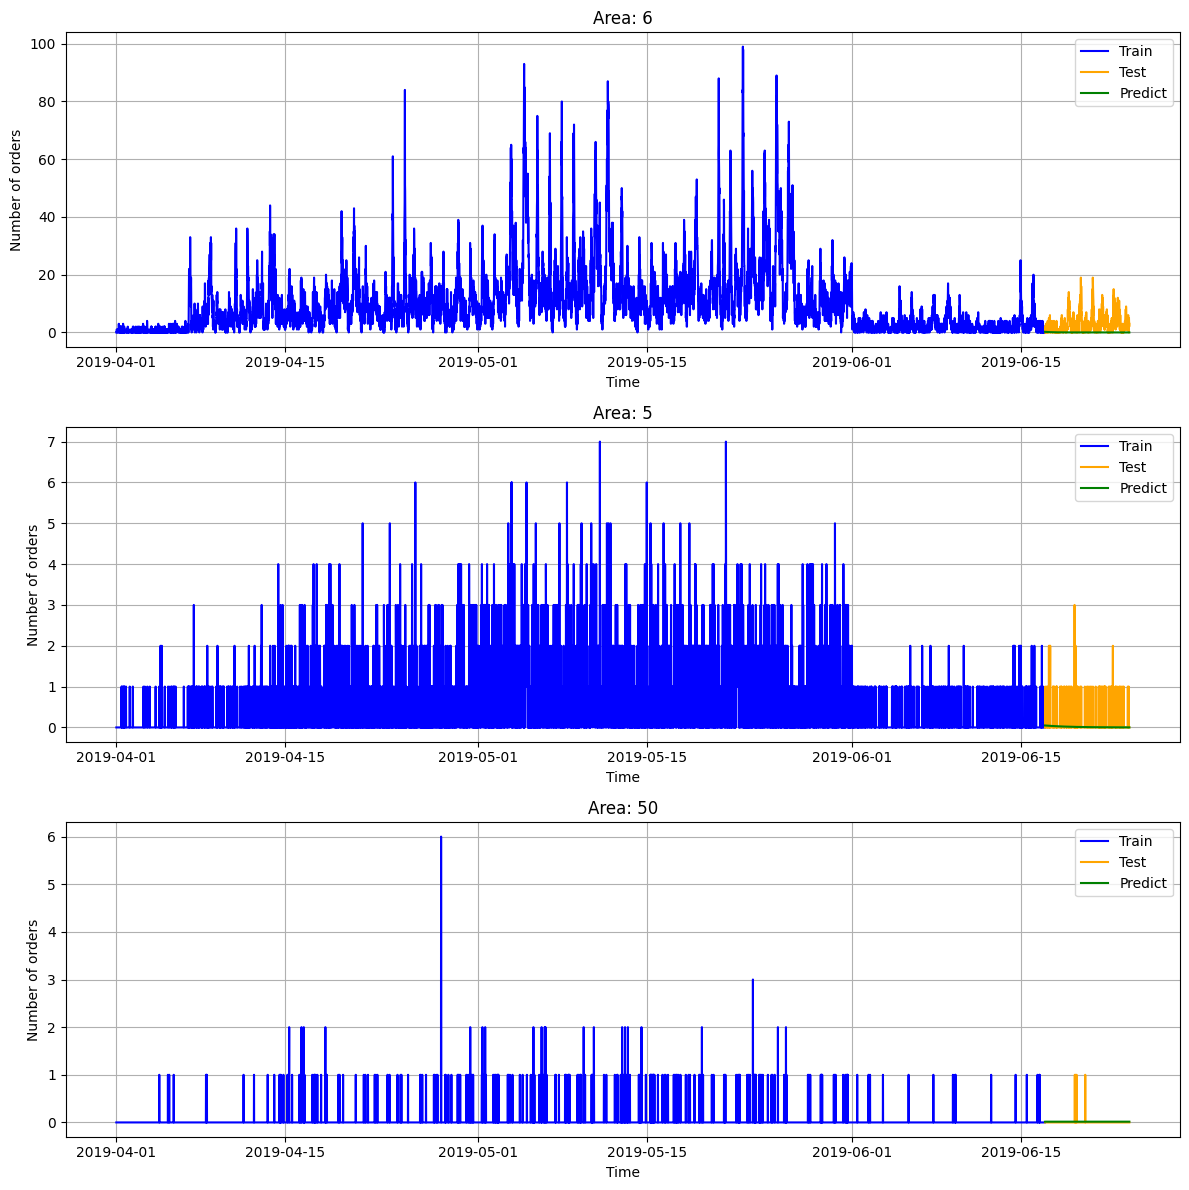

In [26]:
plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=test_predict,
    areas=[6,5,50]
    )

In [27]:
MAE_best_SARIMA = round(mean_absolute_error(test, test_predict), 4)
print(f'MAE на тестовой выборке: {MAE_best_SARIMA}')

MAE на тестовой выборке: 0.7651


### 4. Алгоритм машинного обучения для прогнозирования (CATBOOST)

In [28]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
test_size = 672
areas = [col for col in df.columns if 'Pickup Community Area_' in col]

def create_time_features(df):
    # Извлечь временные признаки
    df_feat = df.copy()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    # df_feat['day'] = df_feat.index.day
    return df_feat

# Создадим лаговые признаки для каждого района
def create_lag_features(df, areas, lags=[
    672,
    672 + 96,
    672 + (96*2),
    672 + (96*3),
    672 + (96*4),
    672 + (96*5),
    672 + (96*6),
    ]):
    for area in areas:
        for lag in lags:
            df[f'{area}_lag_{lag}'] = df[area].shift(lag)
    return df

# Можно добавить скользящее среднее в качестве признака
# !!! Обязательно потом шифтуем на 672 шага вперед, что б не было утечки в валидацию
def create_rolling_features(df, areas, windows=[4, 4*24]):  # например, 1 час и 24 часа
    for area in areas:
        for window in windows:
            df[f'{area}_rolling_mean_{window}'] = df[area].shift(672).rolling(window).mean()
    return df

results = {}

for area in tqdm(areas):

    df_feat = create_time_features(df)
    df_feat = create_lag_features(df_feat, areas=[area])
    df_feat = create_lag_features(df_feat, areas=[area])
    df_feat = df_feat.dropna()
    train_cat = df_feat.iloc[:-test_size]
    test_cat = df_feat.iloc[-test_size:]

    # Формируем признаки X (все кроме районных значений на текущий момент)
    target = train_cat[area]
    # В признаках удалим целевые колонки с текущими значениями районов (но оставим лаги, роллинги)
    drop_cols = areas  # удаляем текущие значения региона, чтобы не "заглядывать в будущее"
    X_cols = train_cat.columns.difference(drop_cols)
    X_train = train_cat[X_cols]
    y_train = target

    X_test = test_cat[X_cols]
    y_test = test_cat[area]

    # Обучаем CatBoost
    model = CatBoostRegressor(
        iterations=2000,
        has_time=True,
        depth=5,
        learning_rate=0.11,
        verbose=100,
        )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=0
        )

    # Прогнозируем
    y_pred = model.predict(X_test)
    results[area] = y_pred

# Собираем результаты в DataFrame
test_predict = pd.DataFrame(results, index=test.index)
test_predict

  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:34<00:00,  2.27it/s]


,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5,Pickup Community Area_6,Pickup Community Area_7,Pickup Community Area_8,Pickup Community Area_9,...,Pickup Community Area_68,Pickup Community Area_69,Pickup Community Area_70,Pickup Community Area_71,Pickup Community Area_72,Pickup Community Area_73,Pickup Community Area_74,Pickup Community Area_75,Pickup Community Area_76,Pickup Community Area_77
Trip Start Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-06-17 00:00:00,3.269650,0.199631,0.169268,0.388208,0.167186,0.092283,1.665801,0.422914,9.314670,0.000783,...,-0.002385,-0.005014,-0.006842,0.001248,0.004995,-0.009796,0.001656,-0.000439,6.666459,0.271937
2019-06-17 00:15:00,3.320126,0.207147,0.108174,0.382206,0.209356,0.088281,1.948190,0.476324,9.234534,0.000783,...,-0.002385,-0.005014,-0.006842,0.001248,0.004995,-0.009796,0.001656,-0.000439,7.107462,0.266269
2019-06-17 00:30:00,3.094683,0.221644,0.169268,0.386521,0.203350,0.064474,1.694583,0.402963,8.087018,0.000783,...,-0.002385,-0.005014,-0.006842,0.001248,0.004995,-0.009796,0.001656,-0.000439,6.210058,0.271937
2019-06-17 00:45:00,3.447208,0.199572,0.113672,0.379614,0.148103,0.088458,1.738404,0.411135,9.070340,0.000783,...,-0.002385,-0.005014,-0.006842,0.001248,0.004995,-0.009796,0.001656,-0.000439,6.249936,0.271937
2019-06-17 01:00:00,0.993792,0.283100,0.042283,0.254119,0.100133,0.079958,1.794655,0.444963,7.826765,0.000783,...,-0.001280,-0.005014,-0.006842,0.001248,0.004995,-0.009796,0.001656,0.002282,2.687254,0.241858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-23 22:45:00,4.927730,0.251880,0.185993,0.646481,0.186874,0.162031,3.226117,1.413380,9.868166,0.004327,...,0.006673,0.007178,0.022733,0.028305,0.009029,0.029755,0.002673,0.011362,15.229219,0.504015
2019-06-23 23:00:00,5.487086,0.281746,0.131368,0.646481,0.196688,0.166497,3.142469,0.997564,12.368776,0.000340,...,0.005375,0.003204,0.020892,0.025459,0.009029,0.029755,0.002673,0.011362,10.482959,0.526693
2019-06-23 23:15:00,5.095392,0.301220,0.182424,0.633591,0.254703,0.162031,3.921074,1.026808,8.356266,0.004327,...,0.005375,0.003204,0.020892,0.025459,0.009029,0.029755,0.002673,0.011362,10.315730,0.526693


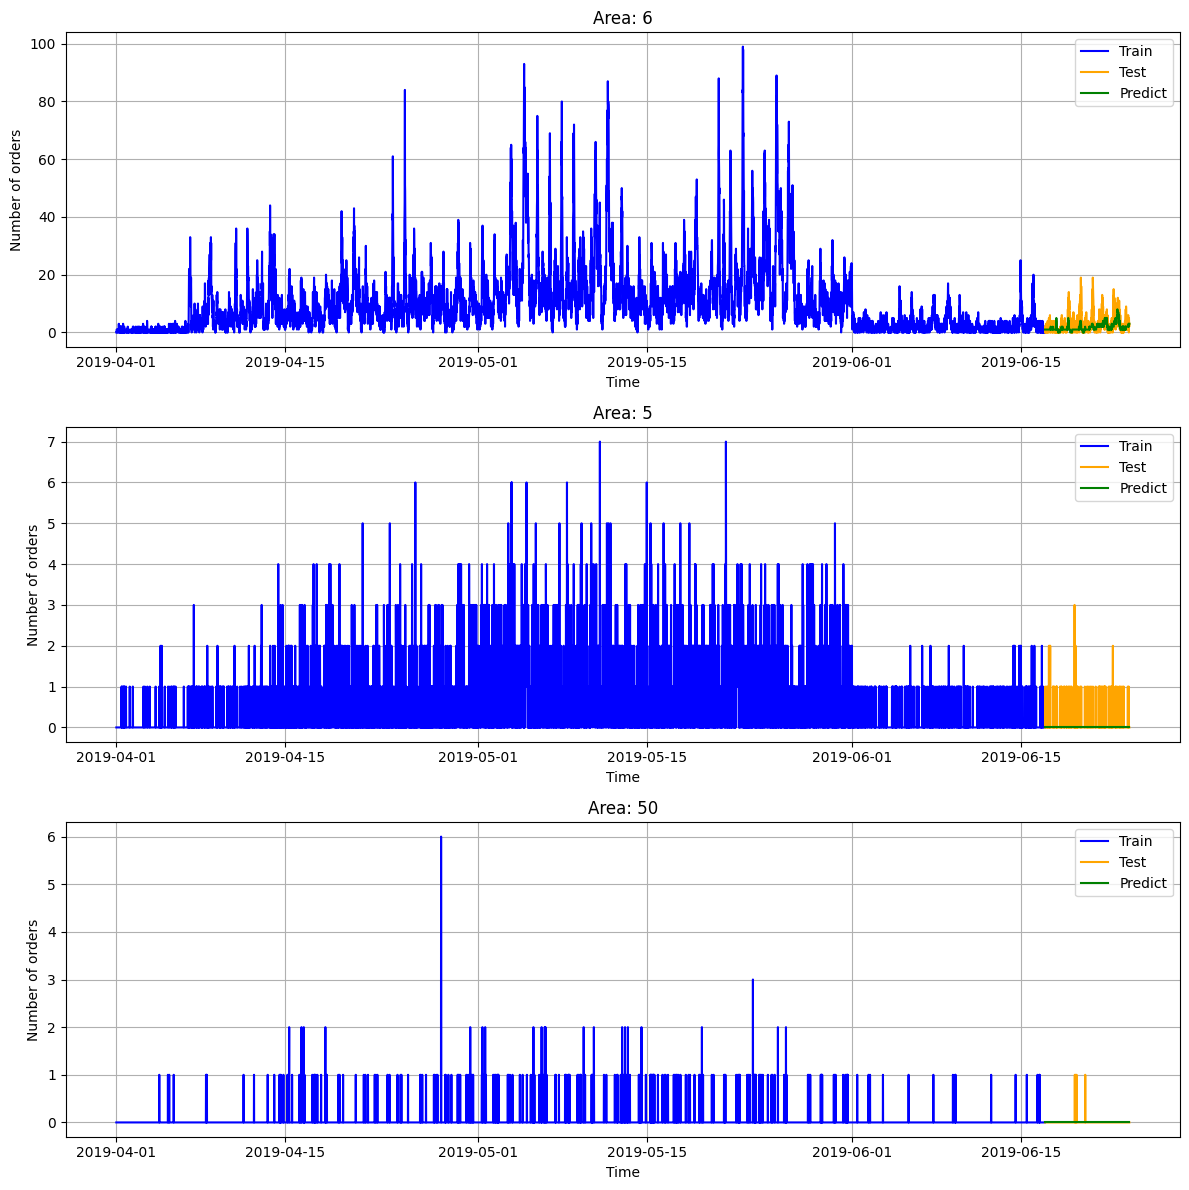

In [29]:
predict_df = test_predict.astype(int)

plot_train_test_predict(
    train_df=train,
    test_df=test,
    predict_df=predict_df,
    areas=[6,5,50]
    )

In [30]:
MAE_best_CATBOOST = round(mean_absolute_error(test, predict_df), 4)
print(f'MAE на тестовой выборке: {MAE_best_CATBOOST}')

MAE на тестовой выборке: 0.3338


### Сравнение метрик MAE различных алгоритмов

In [37]:
print('Глобальная средняя:                      ', MAE_global_mean)
print('Скользящая средняя (лаг-672, окно-3):    ', MAE_rolling_mean)
print('Простое экспоненциальное сглаживание:    ', MAE_exponencial_smooth_simple)
print('Двойное экспоненциальное сглаживание:    ', MAE_exponencial_smooth_double)
print('Тройное экспоненциальное сглаживание:    ', MAE_exponencial_smooth_triple)
print('SARIMA:                                  ', MAE_best_SARIMA)
print('CatBoost:                                ', MAE_best_CATBOOST)

Глобальная средняя:                       3.1035
Скользящая средняя (лаг-672, окно-3):     0.3987
Простое экспоненциальное сглаживание:     0.7562
Двойное экспоненциальное сглаживание:     5.1596
Тройное экспоненциальное сглаживание:     1.8934
SARIMA:                                   0.7651
CatBoost:                                 0.3338
